In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import os

In [2]:
rave_sim_dir = Path('/mnt/d/rave-sim-main/rave-sim-main')
simulations_dir = Path('/mnt/d/rave-sim-main/rave-sim-main/output')
scratch_dir = simulations_dir

In [3]:
sys.path.insert(0, str(rave_sim_dir / "big-wave"))
#print(str(rave_sim_dir / "big-wave"))
import multisim
import config
import util

In [4]:
# ============================================================
# 三组静态制造缺陷靶丸的菲涅耳衍射成像仿真
# ============================================================
GRID_DIR = "/mnt/d/rave-sim-main/rave-sim-main/grid"

shell_configs = [
    {
        "label": "l1_m0_eps002",    # 偶极偏心率
        "grid_path": f"{GRID_DIR}/500um_100um_shell_l1_m0_eps002.npy",
        "desc": "偶极偏心 (l=1, m=0, ε=0.02) — 靶丸沿 z 轴平移偏移 ~4.9µm",
    },
    {
        "label": "l2_m0_eps002",    # P2 椭球度
        "grid_path": f"{GRID_DIR}/500um_100um_shell_l2_m0_eps002.npy",
        "desc": "P₂ 椭球 (l=2, m=0, ε=0.02) — 极向拉伸 1%，赤道收缩 0.6%",
    },
    {
        "label": "l1_varT_er002_et005",  # 壁厚不均匀
        "grid_path": f"{GRID_DIR}/500um_100um_shell_l1_varT_er002_et005.npy",
        "desc": "壁厚不均匀 (l=1, ε_r=0.02, ε_t=0.005) — 内腔偏移 > 外壳偏移",
    },
]

# 公共仿真参数
base_config = {
     "sim_params": {
        "is2d": 'true',
        'use_fresnel_scaling': 'true',
        "N": 4096 * 4096,
        "nx": 4096,
        "ny": 4096,
        "dx": 5e-7,          # 500 nm
        "z_detector": 0.44,     # 探测器位置 0.4 m
        "detector_size": 20e-3,       # 探测器 20 mm
        "detector_size_y": 20e-3,
        "detector_pixel_size_x": 48e-6, # 像素可调
        "detector_pixel_size_y": 48e-6,
        "chunk_size": 2*1024*1024*1024 // 16,
    },
    "use_disk_vector": False,
    "save_debug_wavefields": False,
    "save_final_u_vectors": False,
    "dtype": "c8",
    "multisource": {
        "type": "points",
        "energy_range": [1000, 100001],
        "x_range": [-1e-6, 1e-6],
        "y_range": [-1e-6, 1e-6],
        "z": 0.0,
        "nr_source_points": 1,
        "seed": 1,
        "spectrum": "/mnt/d/rave-sim-main/rave-sim-main/spectrum/spectrum_microX.h5",
    },
    "elements": [
        {
            "type": "sample",
            "z_start": 0.035,            # 样品位于 1.0 m
            "pixel_size_x": 1e-6,      # 样品内部高分辨率
            "pixel_size_y": 1e-6,
            "pixel_size_z": 1e-6,
            "grid_path": None,  # 将被循环填充
            "materials": [["H", 0.255]],
            "x_positions": [0],
            "y_positions": [0],
        },
    ],
}

print(f"共 {len(shell_configs)} 组仿真配置")
for sc in shell_configs:
    print(f"  [{sc['label']}] {sc['desc']}")
print("N:", base_config["sim_params"]["N"])

共 3 组仿真配置
  [l1_m0_eps002] 偶极偏心 (l=1, m=0, ε=0.02) — 靶丸沿 z 轴平移偏移 ~4.9µm
  [l2_m0_eps002] P₂ 椭球 (l=2, m=0, ε=0.02) — 极向拉伸 1%，赤道收缩 0.6%
  [l1_varT_er002_et005] 壁厚不均匀 (l=1, ε_r=0.02, ε_t=0.005) — 内腔偏移 > 外壳偏移
N: 16777216


In [5]:
# ── 依次设置三组仿真 ──
import copy

sim_paths = {}   # label -> sim_path

for sc in shell_configs:
    cfg = copy.deepcopy(base_config)
    cfg["elements"][0]["grid_path"] = sc["grid_path"]
    print(f"\n===== 设置仿真: {sc['label']} =====")
    print(sc["desc"])
    sim_path = multisim.setup_simulation(cfg, Path("."), simulations_dir)
    sim_paths[sc["label"]] = sim_path
    print(f"  → {sim_path}")

print(f"\n✅ 全部 {len(sim_paths)} 组仿真已设置完毕")

2026-06-24 12:10:45,196 INFO: Setting up simulation
2026-06-24 12:10:45,197 INFO: 2D mode: nx=4096, ny=4096, dx=5.000e-07, dy=5.000e-07, detector=(2.000e-02 x 2.000e-02) m



===== 设置仿真: l1_m0_eps002 =====
偶极偏心 (l=1, m=0, ε=0.02) — 靶丸沿 z 轴平移偏移 ~4.9µm


2026-06-24 12:11:53,608 INFO: Fresnel scaling enabled, simulation FOV at sample plane does not need to cover physical detector (8388.61mm vs 20.0mm)
2026-06-24 12:11:53,608 INFO: Fresnel scaling enabled, skipping source→sample Nyquist check
2026-06-24 12:11:53,621 INFO: Fresnel mode: simple cutoff angle=0.0227 rad
2026-06-24 12:13:37,455 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260624_121153973300
2026-06-24 12:13:37,485 INFO: Setting up simulation
2026-06-24 12:13:37,486 INFO: 2D mode: nx=4096, ny=4096, dx=5.000e-07, dy=5.000e-07, detector=(2.000e-02 x 2.000e-02) m


  → /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260624_121153973300

===== 设置仿真: l2_m0_eps002 =====
P₂ 椭球 (l=2, m=0, ε=0.02) — 极向拉伸 1%，赤道收缩 0.6%


2026-06-24 12:14:45,837 INFO: Fresnel scaling enabled, simulation FOV at sample plane does not need to cover physical detector (8388.61mm vs 20.0mm)
2026-06-24 12:14:45,838 INFO: Fresnel scaling enabled, skipping source→sample Nyquist check
2026-06-24 12:14:45,846 INFO: Fresnel mode: simple cutoff angle=0.0227 rad
2026-06-24 12:16:27,251 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260624_121446407183
2026-06-24 12:16:27,280 INFO: Setting up simulation
2026-06-24 12:16:27,281 INFO: 2D mode: nx=4096, ny=4096, dx=5.000e-07, dy=5.000e-07, detector=(2.000e-02 x 2.000e-02) m


  → /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260624_121446407183

===== 设置仿真: l1_varT_er002_et005 =====
壁厚不均匀 (l=1, ε_r=0.02, ε_t=0.005) — 内腔偏移 > 外壳偏移


2026-06-24 12:18:06,411 INFO: Fresnel scaling enabled, simulation FOV at sample plane does not need to cover physical detector (8388.61mm vs 20.0mm)
2026-06-24 12:18:06,412 INFO: Fresnel scaling enabled, skipping source→sample Nyquist check
2026-06-24 12:18:06,430 INFO: Fresnel mode: simple cutoff angle=0.0227 rad
2026-06-24 12:19:43,517 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260624_121806826963


  → /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260624_121806826963

✅ 全部 3 组仿真已设置完毕


In [6]:
# 可选项：查看第一组的 computed 参数
computed = config.load(Path(sim_paths[shell_configs[0]["label"]] / 'computed.yaml'))

In [7]:
# ── 依次运行三组仿真（每组约 10 分钟） ──
for sc in shell_configs:
    label = sc["label"]
    sim_path = sim_paths[label]
    print(f"\n===== 运行仿真: {label} =====")
    print(sc["desc"])
    for i in tqdm(range(base_config["multisource"]["nr_source_points"]), desc=label):
        os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")
    print(f"  ✅ {label} 完成")


===== 运行仿真: l1_m0_eps002 =====
偶极偏心 (l=1, m=0, ε=0.02) — 靶丸沿 z 轴平移偏移 ~4.9µm


l1_m0_eps002:   0%|                                                                               | 0/1 [00:00<?, ?it/s]

[2026-06-24 12:21:39.463] [info] Detector 2D mode
[2026-06-24 12:21:39.465] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260624_121153973300/00000000
[2026-06-24 12:21:39.465] [info] 2D grid: nx = 4096, ny = 4096, total points = 16777216
[2026-06-24 12:21:39.465] [info] GPU memory required for wavefield: 128 MB
[2026-06-24 12:21:39.943] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-06-24 12:21:39.963] [info]   Using Fresnel scaling (z_src=0, avoiding analytical propagation)
[2026-06-24 12:21:39.979] [info]   Fresnel params: z_eff=3.221591e-02, M=12.57x
[2026-06-24 12:21:39.980] [info]   Number of optical elements: 1
[2026-06-24 12:22:27.185] [info]   nx=4096, ny=4096, nr_pixels_x=416, nr_pixels_y=416
[2026-06-24 12:22:27.185] [info]   detector_pixel_size_x=3.818181818181818e-06, detector_pixel_size_y=3.818181818181818e-06 (effective)
[2026-06-24 12:22:27.185] [info]   current_z=0.032215909090909094 (effective), dx=5e-07, d

l1_m0_eps002: 100%|██████████████████████████████████████████████████████████████████████| 1/1 [02:44<00:00, 164.16s/it]


  ✅ l1_m0_eps002 完成

===== 运行仿真: l2_m0_eps002 =====
P₂ 椭球 (l=2, m=0, ε=0.02) — 极向拉伸 1%，赤道收缩 0.6%


...

  ✅ l2_m0_eps002 完成

===== 运行仿真: l1_varT_er002_et005 =====
壁厚不均匀 (l=1, ε_r=0.02, ε_t=0.005) — 内腔偏移 > 外壳偏移


l1_varT_er002_et005:   0%|                                                                        | 0/1 [00:00<?, ?it/s]

[2026-06-24 12:25:49.218] [info] Detector 2D mode
[2026-06-24 12:25:49.220] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260624_121806826963/00000000
[2026-06-24 12:25:49.220] [info] 2D grid: nx = 4096, ny = 4096, total points = 16777216
[2026-06-24 12:25:49.220] [info] GPU memory required for wavefield: 128 MB
[2026-06-24 12:25:49.469] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-06-24 12:25:49.487] [info]   Using Fresnel scaling (z_src=0, avoiding analytical propagation)
[2026-06-24 12:25:49.497] [info]   Fresnel params: z_eff=3.221591e-02, M=12.57x
[2026-06-24 12:25:49.497] [info]   Number of optical elements: 1
[2026-06-24 12:26:33.792] [info]   nx=4096, ny=4096, nr_pixels_x=416, nr_pixels_y=416
[2026-06-24 12:26:33.792] [info]   detector_pixel_size_x=3.818181818181818e-06, detector_pixel_size_y=3.818181818181818e-06 (effective)
[2026-06-24 12:26:33.792] [info]   current_z=0.032215909090909094 (effective), dx=5e-07, d

l1_varT_er002_et005: 100%|███████████████████████████████████████████████████████████████| 1/1 [01:57<00:00, 117.35s/it]

  ✅ l1_varT_er002_et005 完成


In [8]:
# ── 加载三组仿真的波前结果 ──
results = {}   # label -> wavefront (2D array)

for sc in shell_configs:
    label = sc["label"]
    sim_path = sim_paths[label]
    wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-2e-6, 2e-6))
    print(f"[{label}] 加载源点数: {len(wavefronts)}")
    wavef = [result[0] for result in wavefronts]
    wf = np.sum(wavef, axis=0)
    print(f"  波前形状: {wf.shape} (相位步进={wf.shape[0]}, 探测器像素={wf.shape[1]}×{wf.shape[2]})")
    results[label] = wf

[l1_m0_eps002] 加载源点数: 1
  波前形状: (1, 416, 416) (相位步进=1, 探测器像素=416×416)
[l2_m0_eps002] 加载源点数: 1
  波前形状: (1, 416, 416) (相位步进=1, 探测器像素=416×416)
[l1_varT_er002_et005] 加载源点数: 1
  波前形状: (1, 416, 416) (相位步进=1, 探测器像素=416×416)


/tmp/ipykernel_2266/3070025913.py:19: UserWarning: Glyph 20598 (\N{CJK UNIFIED IDEOGRAPH-5076}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2266/3070025913.py:19: UserWarning: Glyph 26497 (\N{CJK UNIFIED IDEOGRAPH-6781}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2266/3070025913.py:19: UserWarning: Glyph 20559 (\N{CJK UNIFIED IDEOGRAPH-504F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2266/3070025913.py:19: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2266/3070025913.py:19: UserWarning: Glyph 26925 (\N{CJK UNIFIED IDEOGRAPH-692D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2266/3070025913.py:19: UserWarning: Glyph 29699 (\N{CJK UNIFIED IDEOGRAPH-7403}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2266/3070025913.py:19: UserWarning: Glyph 22721 (\N{CJK UNIFIED IDEOGRAPH-58C1}

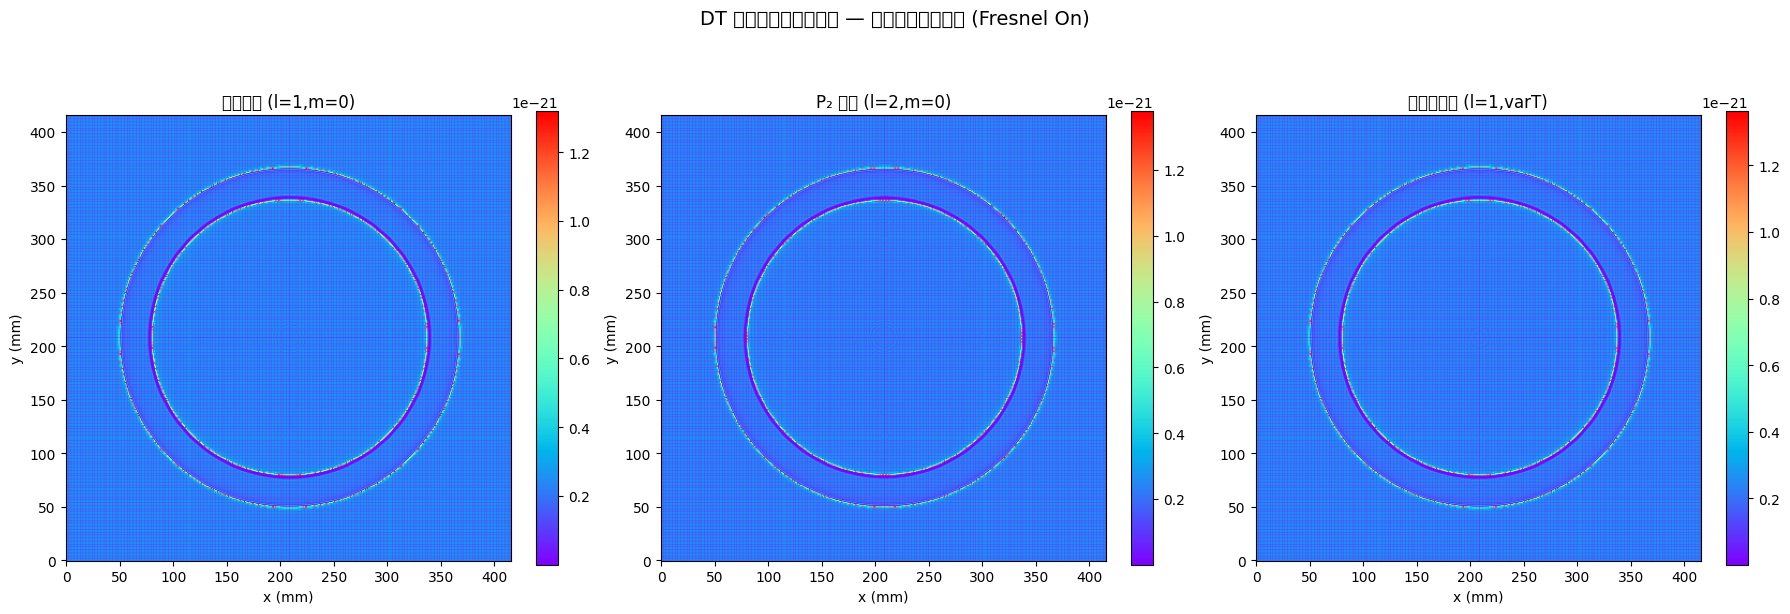

已保存对比图: /mnt/d/rave-sim-main/rave-sim-main/output/comparison_3shells_2d.png


In [9]:
# ============================================================
# 成像结果对比：三组靶丸的衍射图样
# ============================================================
sp = base_config["sim_params"]

# 探测器坐标 (mm)
# ─── 1. 三张并排的 2D 衍射图 ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
labels_zh = ["偶极偏心 (l=1,m=0)", "P₂ 椭球 (l=2,m=0)", "壁厚不均匀 (l=1,varT)"]

for idx, (label, wf) in enumerate(results.items()):
    im = axes[idx].imshow(abs(wf[0])**2, cmap='rainbow', origin='lower')
    axes[idx].set_title(labels_zh[idx], fontsize=12)
    axes[idx].set_xlabel('x (mm)')
    axes[idx].set_ylabel('y (mm)')
    plt.colorbar(im, ax=axes[idx], fraction=0.046)

plt.suptitle("DT 靶丸菲涅耳衍射成像 — 静态制造缺陷对比 (Fresnel On)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(simulations_dir / "comparison_3shells_2d.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"已保存对比图: {simulations_dir / 'comparison_3shells_2d.png'}")

NameError: name 'detector_x' is not defined

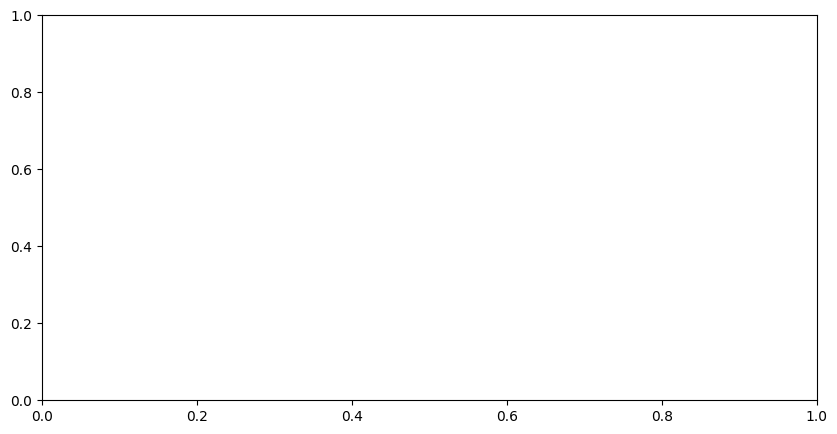

In [10]:
# ─── 2. 中心行 lineout 对比 ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
center_y = wf.shape[1] // 2

for idx, (label, wf) in enumerate(results.items()):
    lineout = abs(wf[0, center_y, :])**2
    ax.plot(detector_x * 1e3, lineout, label=labels_zh[idx], lw=1.5)

ax.set_xlabel('x (mm)')
ax.set_ylabel('Intensity (a.u.)')
ax.set_title('中心行线剖面对比')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(simulations_dir / "comparison_3shells_lineout.png", dpi=150)
plt.show()
print(f"已保存: {simulations_dir / 'comparison_3shells_lineout.png'}")

# ─── 3. 两两差异图 ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
pairs = [("l1_m0_eps002", "l2_m0_eps002"),
         ("l1_m0_eps002", "l1_varT_er002_et005"),
         ("l2_m0_eps002", "l1_varT_er002_et005")]
pair_labels = ["(偶极偏心) − (P₂椭球)",
               "(偶极偏心) − (壁厚不均)",
               "(P₂椭球) − (壁厚不均)"]

for ax, (a, b), title in zip(axes, pairs, pair_labels):
    diff = abs(results[a][0])**2 - abs(results[b][0])**2
    im = ax.imshow(diff, extent=extent, cmap='RdBu', origin='lower')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    plt.colorbar(im, ax=ax, fraction=0.046, label='ΔI')

plt.suptitle("两两差异图", fontsize=14)
plt.tight_layout()
plt.savefig(simulations_dir / "comparison_3shells_diff.png", dpi=150, bbox_inches='tight')
plt.show()
print("全部对比图已保存")